<a href="https://colab.research.google.com/github/Odeyiany2/ACCESS-6.0-Skills-Acquisition-Program-Data-Science/blob/main/week%207/Week_7_Session_13_Classification_Modeling%2C_Evaluation_%26_Tuning_(Loan_Approval_Prediction)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Session 13 - Classification Modeling, Evaluation & Tuning (Loan Approval Prediction)**

This notebook is designed for teaching core classification concepts end-to-end. It intentionally emphasizes imbalance handling, cross-validation, tuning, and stacking.

We will:
1. Load and inspect the dataset  
2. Understand **class imbalance**  
3. Apply **SMOTE step-by-step (outside a pipeline)**  
4. Build models **without SMOTE**  
5. Build models **with SMOTE inside a pipeline**  
6. Evaluate and compare results  


In [ ]:
# Imports & Setup
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')


### **Data Loading and Inspection**

Dataset: Loan Approval Prediction (Kaggle) - https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data
Target variable: Loan_Status (Approved = 1 / Rejected = 0)

In [ ]:
df = pd.read_csv("/content/loan_data (1).csv")

In [ ]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
df.shape

(45000, 14)

In [ ]:
#change the dtype of the columns - person_age and cb_person_cred_hist_length
df["person_age"] = df["person_age"].astype(int)
df["cb_person_cred_hist_length"] = df["cb_person_cred_hist_length"].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
df.describe().T #statistics summary

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


## **Target Variable Check**

In [ ]:
df['loan_status'].value_counts()

,count
loan_status,
0,35000
1,10000


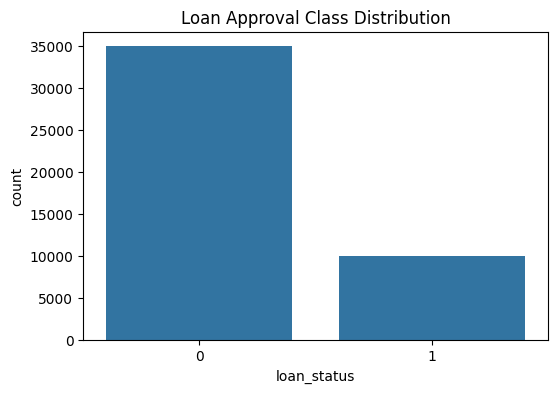

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df)
plt.title('Loan Approval Class Distribution')
plt.show()

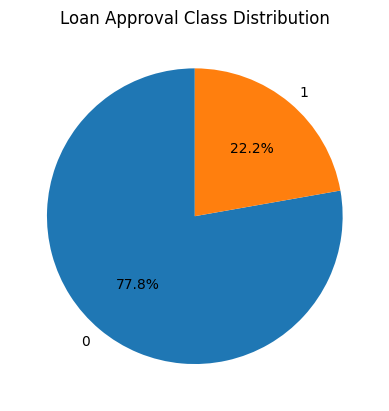

In [ ]:
#pie chart using plt
loan_values = df["loan_status"].value_counts()

plt.pie(loan_values, labels = loan_values.index, startangle=90, autopct="%1.1f%%")
plt.title("Loan Approval Class Distribution")
plt.show()

## **Feature and Target Split**

In [ ]:
X = df.drop('loan_status', axis=1) #features
y = df['loan_status'] #target variable


#columns splitting into numeric and object
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print(num_cols)
print(cat_cols)

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='object')
Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object')


In [ ]:
X.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
0,22,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3,561,No
1,21,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2,504,Yes
2,25,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3,635,No
3,23,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2,675,No
4,24,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4,586,No


## **Prepocessing Pipelines**

In [ ]:

num_pipeline = Pipeline(steps=[
('scaler', StandardScaler())
])


cat_pipeline = Pipeline(steps=[
('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])


preprocessor = ColumnTransformer(transformers=[
('num', num_pipeline, num_cols),
('cat', cat_pipeline, cat_cols)
])

In [ ]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object'))])

## **Train Test Split (Using the Stratify Method to Handle the imbalance)**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
stratify=y,
random_state=42
)

## **Baseline Model - Logistic Regression**

In [ ]:
#logistic regression
model_log = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state = 42))
])

#train the model
model_log.fit(X_train, y_train)

#make predictions
y_pred_log = model_log.predict(X_test)
#y_pred_log = model_log.predict_proba(X_test)[:, 1]

print(f"Classification Report")
print(classification_report(y_test, y_pred_log))

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000



## **Handling Imbalance with SMOTE**

SMOTE - Synthetic Minority Oversampling Technique

class weights

random forest - ensemble method

undersampling

threshold tuning


### DO NOT APPLY SMOTE TO TEST DATASET

In [ ]:
#adding smote to our pipeline

smote_pipeline = ImbPipeline(steps = [
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter = 1000, random_state = 42))

])

smote_pipeline.fit(X_train, y_train)
y_pred_smote = smote_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7000
           1       0.63      0.91      0.75      2000

    accuracy                           0.86      9000
   macro avg       0.80      0.88      0.83      9000
weighted avg       0.90      0.86      0.87      9000



### **Check against pipelines**

In [ ]:
#preprocessing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_cols])

encoder = OneHotEncoder(handle_unknown='ignore', drop='first')
X_train_encoded = encoder.fit_transform(X_train[cat_cols])


In [ ]:
#using smote without the pipeline
smote = SMOTE(random_state = 42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
y_train_smote.value_counts()

,count
loan_status,
0,28000
1,28000


In [ ]:
#building our model

model_log_smote = LogisticRegression(max_iter = 1000, random_state = 42)
model_log_smote.fit(X_train_smote, y_train_smote)

#predictions on X_test
X_test_scaled = scaler.transform(X_test[num_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

In [ ]:
#make predictiosn
y_pred_log_smote = model_log_smote.predict(X_test_scaled)
print(classification_report(y_test, y_pred_log_smote))

              precision    recall  f1-score   support

           0       0.92      0.77      0.84      7000
           1       0.49      0.76      0.60      2000

    accuracy                           0.77      9000
   macro avg       0.70      0.77      0.72      9000
weighted avg       0.82      0.77      0.79      9000



In [ ]:
#try another model

random_model = RandomForestClassifier(random_state = 42)

random_model.fit(X_train_scaled, y_train)
y_pred_random = random_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_random))

              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7000
           1       0.78      0.61      0.68      2000

    accuracy                           0.87      9000
   macro avg       0.84      0.78      0.80      9000
weighted avg       0.87      0.87      0.87      9000



## **Cross Validation with StratifiedKFold**

In [ ]:
smote_pipeline_2 = ImbPipeline(steps = [
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(random_state = 42))

])


In [ ]:
#cv = 5

#stratifiedKfold - ensures that each fold has the same class distribution

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

cross_scores = cross_val_score(
    smote_pipeline_2,
    X_train,
    y_train,
    cv = cv,
    scoring = "roc_auc"
)

print("CV ROC AUC:", cross_scores)
print("Mean ROC AUC:", cross_scores.mean())

CV ROC AUC: [0.97108532 0.96810318 0.97286596 0.97150887 0.97291908]
Mean ROC AUC: 0.9712964843749999


 - ROC AUC = Area Under the Receiver Operating Characteristic Curve (ROC AUC)

 - 0 to 1: closer to one (model is perfect)

## **Tree Based Models**

## **HyperParameter Tuning**

In [ ]:
#parameter tuning
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2,5]
}

grid = GridSearchCV(
    smote_pipeline_2,
    param_grid,
    cv = cv,
    scoring = "roc_auc",
    n_jobs = -1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV Score: 0.9717634263392856


## **Overfitting Check**

In [ ]:
#overfitting check
best_model = grid.best_estimator_

#test data
y_pred_best = best_model.predict(X_test)
test_score = roc_auc_score(y_test, y_pred_best)


#training data
y_pred_train = best_model.predict(X_train)
train_score = roc_auc_score(y_train, y_pred_train)

print("Train Score:", train_score)
print("Test Score:", test_score)


Train Score: 0.9977410714285714
Test Score: 0.8899285714285714


Other models

- LightGBM
- ExtraTrees
- Adaboost
- XGBoost
- GradientBoosting

## **Stacking Classifier**

In [ ]:
##stacking classifier

estimators = [
    ("log_reg", LogisticRegression(max_iter = 1000)),
    ("rf", RandomForestClassifier(random_state = 42))
]

stack_model = StackingClassifier(
    estimators = estimators,
    final_estimator = LogisticRegression(),
    cv = cv
)


stack_pipe = ImbPipeline(steps = [
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("stack_model", stack_model)
]
)

stack_pipe.fit(X_train, y_train)

y_pred_stack = stack_pipe.predict(X_test)

print(classification_report(y_test, y_pred_stack))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7000
           1       0.85      0.80      0.82      2000

    accuracy                           0.92      9000
   macro avg       0.89      0.88      0.89      9000
weighted avg       0.92      0.92      0.92      9000



## **Feature Importance**

In [ ]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importance_score = best_model.named_steps["classifier"].feature_importances_

df_importance = pd.DataFrame({
    "feature":feature_names,
    "importance": importance_score
}).sort_values(by = "importance", ascending = False)

df_importance.head()

,feature,importance
21,cat__previous_loan_defaults_on_file_Yes,0.344690
4,num__loan_int_rate,0.133107
5,num__loan_percent_income,0.122288
1,num__person_income,0.088817
15,cat__person_home_ownership_RENT,0.071349


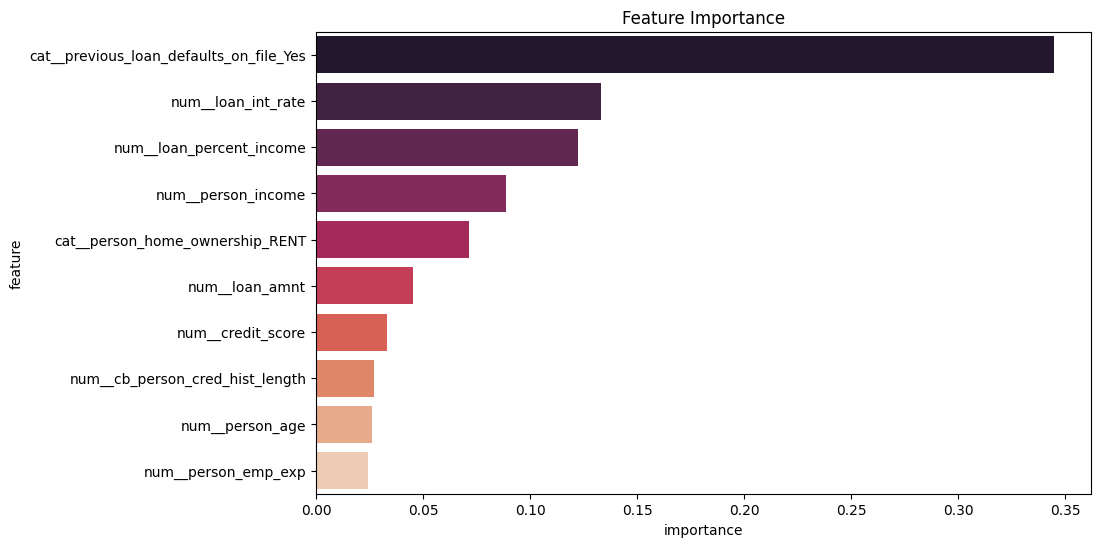

In [ ]:
#visualize the feature importance - top 10
top_10 = df_importance.head(10)
plt.figure(figsize = (10,6))
sns.barplot(data = top_10, x = "importance", y = "feature", palette="rocket")
plt.title("Feature Importance")
plt.show()
